PIE_DIR   : ./PIE
SELFIE_DIR: ./SELFIES
The 25 randomly chosen subjects: [2, 4, 5, 8, 14, 15, 16, 18, 19, 20, 22, 24, 25, 29, 30, 39, 43, 44, 47, 48, 49, 54, 59, 62, 63]
Number of Training Samples: 2982 2975 7
Number of Testing Samples: 1278 1275 3
Class numbers: 26
Classes: ['PIE_2', 'PIE_4', 'PIE_5', 'PIE_8', 'PIE_14', 'PIE_15', 'PIE_16', 'PIE_18', 'PIE_19', 'PIE_20', 'PIE_22', 'PIE_24', 'PIE_25', 'PIE_29', 'PIE_30', 'PIE_39', 'PIE_43', 'PIE_44', 'PIE_47', 'PIE_48', 'PIE_49', 'PIE_54', 'PIE_59', 'PIE_62', 'PIE_63', 'SELF']


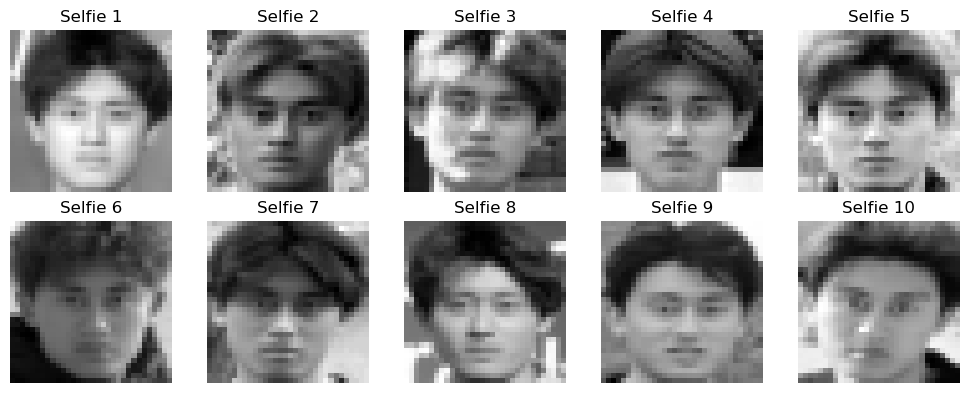

Training Dataset size: (2982, 1024) 
Testing Dataset size: (1278, 1024) 26


In [ ]:
import os
import glob
import random
from typing import List, Tuple, Dict

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# 1. Part1 Feature Extraction with PCA and LDA


## 1.1 Dataset Preparation

# ==========================================================
# Basic: Seed and Path setting
# ==========================================================


SEED = 181
random.seed(SEED)
np.random.seed(SEED)

ROOT_DIR = "."  # Current Directory: A0329181A_SUIZHUOYUAN_CA2
PIE_DIR = os.path.join(ROOT_DIR, "PIE")
SELFIE_DIR = os.path.join(ROOT_DIR, "SELFIES")
SUBJECT_DIR_PATTERN = os.path.join(PIE_DIR, "{sid:d}")

print("PIE_DIR   :", PIE_DIR)
print("SELFIE_DIR:", SELFIE_DIR)


# ==========================================================
# Dataset preparation for PIE data
# ==========================================================


def get_image_paths_for_subject(subject_id: int):
    """
    Return the image path for certain subject
    """
    subject_dir = SUBJECT_DIR_PATTERN.format(sid=subject_id)
    patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp"]
    img_paths = []
    for pattern in patterns:
        img_paths.extend(glob.glob(os.path.join(subject_dir, pattern)))

    img_paths = sorted(img_paths)
    return img_paths


def train_test_split_paths(paths: List[str], train_ratio: float = 0.7):
    """
    Split the TRAIN & TEST set with ratio =0.7 and Use global random (seed=181) to shuffle.
    """
    paths_shuffled = paths.copy()
    random.shuffle(paths_shuffled)

    n_total = len(paths_shuffled)
    n_train = int(round(train_ratio * n_total))

    train_paths = paths_shuffled[:n_train]
    test_paths = paths_shuffled[n_train:]

    return train_paths, test_paths


def prepare_cmu_pie_data(selected_subjects: List[int]):
    """
    Construct the datasets for PIE
    """
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    label_map: Dict[int, int] = {}

    for class_idx, subject_name in enumerate(selected_subjects, start=1):
        label_map[subject_name] = class_idx

        img_paths = get_image_paths_for_subject(subject_name)
        if len(img_paths) == 0:
            raise RuntimeError(f"No images found for subject folder: {subject_name}")

        train_paths, test_paths = train_test_split_paths(img_paths, train_ratio=0.7)

        # Training Set
        for p in train_paths:
            img = Image.open(p)
            img_2d = np.asarray(img, dtype=np.float32) / 255.0
            img_flat = img_2d.flatten()
            X_train_list.append(img_flat)
            y_train_list.append(class_idx)

        # Testing set
        for p in test_paths:
            img = Image.open(p)
            img_2d = np.asarray(img, dtype=np.float32) / 255.0
            img_flat = img_2d.flatten()
            X_test_list.append(img_flat)
            y_test_list.append(class_idx)

    X_train = np.vstack(X_train_list)
    X_test = np.vstack(X_test_list)
    y_train = np.array(y_train_list, dtype=int)
    y_test = np.array(y_test_list, dtype=int)

    return X_train, y_train, X_test, y_test, label_map


# ==========================================================
# Dataset preparation for SELFIES
# ==========================================================


def load_and_preprocess_image(img_path: str, size: Tuple[int, int] = (32, 32)):
    """
    Load image, perform grayscale, normalization and flatten to 1024 vector.
    """

    img = Image.open(img_path).convert("L")  # Gray scale
    img = img.resize(size, Image.BILINEAR)  # flatten to 32x32

    img_2d = (
        np.asarray(img, dtype=np.float32) / 255.0
    )  # Normalize the pixel values to [0, 1].
    img_flat = img_2d.flatten()

    return img_2d, img_flat


def prepare_selfie_data(selfie_dir: str, img_size: Tuple[int, int] = (32, 32)):
    """
    Construct the datasets for SELFIES.
    """
    patterns = ["*.png", "*.jpg", "*.jpeg", "*.bmp"]
    selfie_paths = []
    for pattern in patterns:
        selfie_paths.extend(glob.glob(os.path.join(selfie_dir, pattern)))
    selfie_paths = sorted(selfie_paths)

    if len(selfie_paths) != 10:
        raise RuntimeError(f"Expected 10 selfie images, found {len(selfie_paths)}")

    selfie_images_2d: List[np.ndarray] = []
    selfie_flat_list: List[np.ndarray] = []

    for p in selfie_paths:
        img_2d, img_flat = load_and_preprocess_image(p, size=img_size)
        selfie_images_2d.append(img_2d)
        selfie_flat_list.append(img_flat)

    selfie_flat = np.vstack(selfie_flat_list)  # (10, 1024)

    # Shuffle
    random.shuffle(selfie_paths)

    # Divided by 7:3
    X_train_self = selfie_flat[:7]
    X_test_self = selfie_flat[7:]

    y_train_self = np.full(7, -1, dtype=int)  # 占位
    y_test_self = np.full(3, -1, dtype=int)

    return X_train_self, y_train_self, X_test_self, y_test_self, selfie_images_2d


def show_preprocessed_selfies(selfie_images_2d: List[np.ndarray]):
    """
    Dispaly the preprocessed selfies
    """
    n = len(selfie_images_2d)

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.ravel()

    for i in range(n):
        axes[i].imshow(selfie_images_2d[i], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Selfie {i+1}")

    plt.tight_layout()
    plt.show()


# ==========================================================
# Construct the Dataset and display the preprocessed selfies
# ==========================================================


def prepare_full_dataset():
    # Randomly choose 25 subjects
    all_subject_dirs = list(range(1, 69))
    selected_subjects = random.sample(all_subject_dirs, 25)
    selected_subjects = sorted(selected_subjects)  # 排序便于查看
    print("The 25 randomly chosen subjects:", selected_subjects)

    # CMU PIE part
    X_train_cmu, y_train_cmu, X_test_cmu, y_test_cmu, label_map = prepare_cmu_pie_data(
        selected_subjects
    )

    # Selfies part
    X_train_self, y_train_self, X_test_self, y_test_self, selfie_imgs_2d = (
        prepare_selfie_data(SELFIE_DIR)
    )

    # Assign SELFIE a new class index: 25
    selfie_class_index = len(label_map)  # 25
    y_train_self[:] = selfie_class_index
    y_test_self[:] = selfie_class_index

    # Combine CMU PIE and SELFIE
    X_train = np.vstack([X_train_cmu, X_train_self])
    X_test = np.vstack([X_test_cmu, X_test_self])

    y_train = np.concatenate([y_train_cmu, y_train_self])
    y_test = np.concatenate([y_test_cmu, y_test_self])

    # Class name: 0-24: CMU PIE; 25: SELF
    class_names = []
    for subject_name, class_idx in sorted(label_map.items(), key=lambda x: x[1]):
        class_names.append(f"PIE_{subject_name}")
    class_names.append("SELF")

    print(
        "Number of Training Samples:",
        X_train.shape[0],
        X_train_cmu.shape[0],
        X_train_self.shape[0],
    )
    print(
        "Number of Testing Samples:",
        X_test.shape[0],
        X_test_cmu.shape[0],
        X_test_self.shape[0],
    )
    print("Class numbers:", len(class_names))
    print("Classes:", class_names)

    # Show 10 selfie
    show_preprocessed_selfies(selfie_imgs_2d)

    return X_train, y_train, X_test, y_test, class_names


# ==========================================================
# Main
# ==========================================================
X_train, y_train, X_test, y_test, class_names = prepare_full_dataset()

print(
    "Training Dataset size:",
    X_train.shape,
    "\nTesting Dataset size:",
    X_test.shape,
    len(class_names),
)

Z_train_pca2 shape: (2982, 2)
PCA(2) components_ shape: (2, 1024)
PCA(2) explained variance ratio: [0.4507002  0.24874073]
Index of SELF class: 25
Z_train_pca3 shape: (2982, 3)
PCA(3) components_ shape: (3, 1024)
PCA(3) explained variance ratio: [0.4507002  0.24874073 0.06606061]


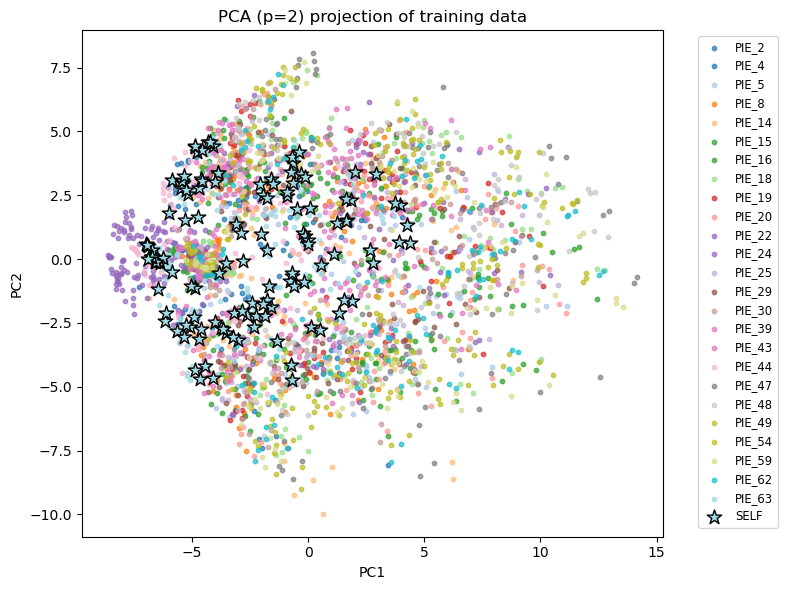

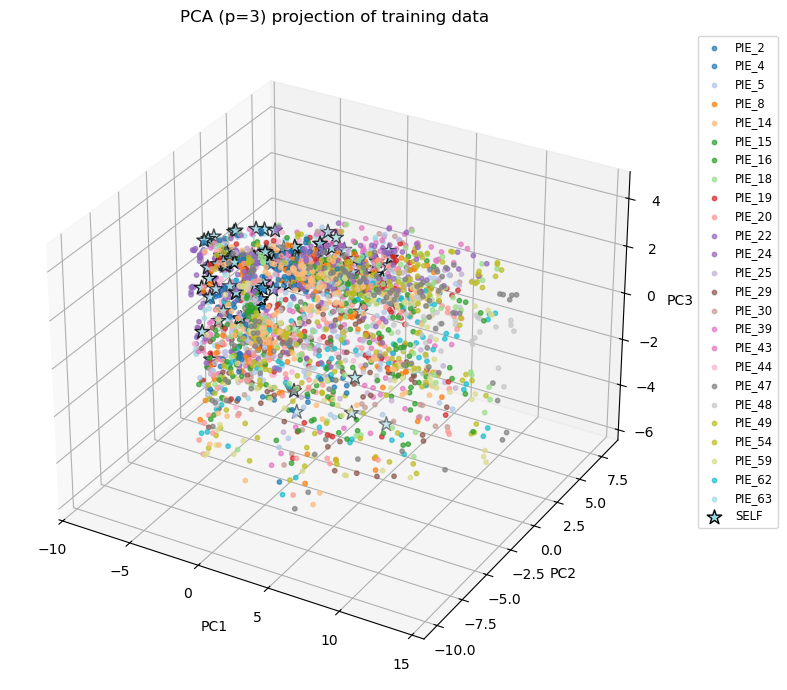

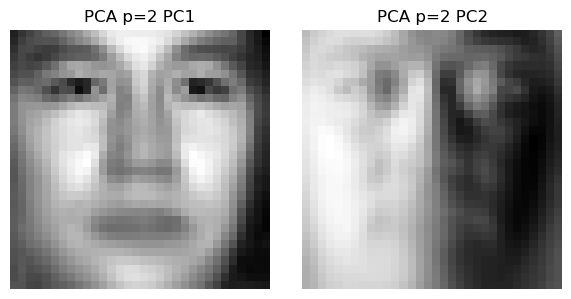

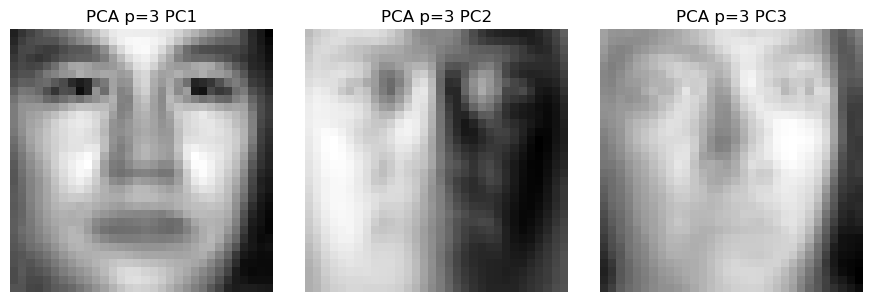

PCA p=100:
  X_train_pca100 shape: (2982, 100)
  X_test_pca100 shape : (1278, 100)

PCA p=300:
  X_train_pca300 shape: (2982, 300)
  X_test_pca300 shape : (1278, 300)


In [2]:
import numpy as np


## 1.2 PCA for feature extraction and visualization


# ==========================================================
# PCA
# ==========================================================


class MyPCA:
    """
    Simple PCA implementation:
        - P: number of principal components to keep
        - fit(X):       compute PCA on training data
        - transform(X): project new data onto the PCs
        - fit_transform(X): convenience method
        - inverse_transform(Z): reconstruct original data from PCs
    """

    def __init__(self, P: int):
        self.P: int = P
        self.mean = None  # (D,)
        self.components = None  # (p, D), PCA directions
        self.explained_variance = None  # (N,)
        self.explained_variance_ratio = None  # (N,)

    def fit(self, X: np.ndarray):
        """
        Fit PCA on data X.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Each row is one flattened image (e.g., 32*32 = 1024 features).
        """
        # 1. Compute feature-wise mean and Centered data matrix
        self.mean = np.mean(X, axis=0)  # (D,)
        X_centered = X - self.mean  # (N, D)

        # 2. Compute covariance matrix C
        n_samples = X_centered.shape[0]
        C = (X_centered.T @ X_centered) / (n_samples - 1)  # (D, D)

        # 3. Eigen-decomposition of the covariance matrix
        eigvals, eigvecs = np.linalg.eigh(C)

        # 4. Sort eigenvalues and eigenvectors
        idx = np.argsort(eigvals)[::-1]  # indices in descending order
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]  # (D, 1)

        # 5. Keep the first P principal directions
        p = self.P
        self.components = eigvecs[:, :p].T  # (p, D), each row is one PC
        self.explained_variance = eigvals[:p]

        # 6. Variance ratio for each selected component
        total_var = eigvals.sum()
        self.explained_variance_ratio = self.explained_variance / total_var

        return self

    def transform(self, X: np.ndarray):
        """
        Project data X onto the principal components (after calling fit).

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)

        Returns
        -------
        Z : ndarray of shape (n_samples, p_directions),
            Low-dimensional representation of X in the PCA subspace.
        """
        if self.mean is None or self.components is None:
            raise RuntimeError("MyPCA is not fitted yet. Call fit(X) first.")

        X_centered = X - self.mean  # (N, D)

        # Project data onto PCs
        Z = X_centered @ self.components.T  # (N, p) = (N,D) @ (D,p)
        return Z

    def fit_transform(self, X: np.ndarray):
        """
        Qucik fit and transform
        """
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, Z: np.ndarray):
        """
        Reconstruct an approximation of the original data from PCA features.

        Parameters
        ----------
        Z : ndarray of shape (n_samples, N)

                Returns
        -------
        X_recon : ndarray of shape (n_samples, n_features)
        """
        if self.mean is None or self.components is None:
            raise RuntimeError("MyPCA is not fitted yet. Call fit(X) first.")

        # Z * W + mean, where W is components with shape (p, D)
        X_recon = Z @ self.components + self.mean  # (N, D)
        return X_recon


# ==========================================================
# Apply PCA with number of PCs to be 2 and 3
# ==========================================================

pca2 = MyPCA(P=2)
Z_train_pca2 = pca2.fit_transform(X_train)

print("Z_train_pca2 shape:", Z_train_pca2.shape)
print("PCA(2) components_ shape:", pca2.components.shape)  # (2, 1024)
print("PCA(2) explained variance ratio:", pca2.explained_variance_ratio)

self_class_idx = class_names.index("SELF")
print("Index of SELF class:", self_class_idx)

pca3 = MyPCA(P=3)
Z_train_pca3 = pca3.fit_transform(X_train)  # shape: (N_train, 3)

print("Z_train_pca3 shape:", Z_train_pca3.shape)
print("PCA(3) components_ shape:", pca3.components.shape)  # (3, 1024)
print("PCA(3) explained variance ratio:", pca3.explained_variance_ratio)

# ==========================================================
# Visualization
# ==========================================================


def plot_2d(Z, y, class_names, self_class_idx, xlabel="", ylabel="", title=""):
    """
    Plot 2D PCA projection of training data.
    Each class uses a different color.
    The SELF class is highlighted with star markers.
    """
    n_classes = len(class_names)
    cmap = plt.get_cmap("tab20", n_classes)  # discrete colormap

    plt.figure(figsize=(8, 6))

    for c in range(n_classes):
        mask = y == c
        Xc = Z[mask]

        if c == self_class_idx:
            # Highlight SELF images
            plt.scatter(
                Xc[:, 0],
                Xc[:, 1],
                s=120,
                marker="*",
                c=[cmap(c)],
                edgecolors="black",
                linewidths=1.0,
                label=class_names[c],
            )
        else:
            plt.scatter(
                Xc[:, 0], Xc[:, 1], s=10, c=[cmap(c)], alpha=0.7, label=class_names[c]
            )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize="small", ncol=1)
    plt.tight_layout()
    plt.show()


# Plot the Projected 2d data
plot_2d(
    Z_train_pca2,
    y_train,
    class_names,
    self_class_idx,
    xlabel="PC1",
    ylabel="PC2",
    title="PCA (p=2) projection of training data",
)


def plot_3d(
    Z, y, class_names, self_class_idx, xlabel="", ylabel="", zlabel="", title=""
):
    """
    Plot 3D PCA projection of training data.
    Each class uses a different color.
    The SELF class is highlighted with star markers.
    """
    n_classes = len(class_names)
    cmap = plt.get_cmap("tab20", n_classes)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    for c in range(n_classes):
        mask = y == c
        Xc = Z[mask]

        xs = Xc[:, 0]
        ys = Xc[:, 1]
        zs = Xc[:, 2]

        if c == self_class_idx:
            ax.scatter(
                xs,
                ys,
                zs,
                s=120,
                marker="*",
                c=[cmap(c)],
                edgecolors="black",
                linewidths=1.0,
                label=class_names[c],
            )
        else:
            ax.scatter(xs, ys, zs, s=10, c=[cmap(c)], alpha=0.7, label=class_names[c])

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()


# Plot the Projected 3d data
plot_3d(
    Z_train_pca3,
    y_train,
    class_names,
    self_class_idx,
    xlabel="PC1",
    ylabel="PC2",
    zlabel="PC3",
    title="PCA (p=3) projection of training data",
)

# ==========================================================
# Eigenface
# ==========================================================


def show_eigenfaces(
    components: np.ndarray, img_shape=(32, 32), num_faces=None, title_prefix=""
):
    """
    Visualize eigenfaces by reshaping each PC vector to 2D images.

    Parameters
    ----------
    components : ndarray of shape (p, D)
        Each row is one PC vector.
    img_shape : tuple
        Shape of the original image (height, width).
    num_faces : int or None
        Number of fisherfaces to show. If None, use all directions.
    title_prefix : str
        Text prefix for subplot titles.
    """
    if num_faces is None:
        num_faces = components.shape[0]

    plt.figure(figsize=(3 * num_faces, 3))

    for i in range(num_faces):
        vec = components[i]  # shape: (D,)
        # Reshape to 2D
        eigenface = vec.reshape(img_shape)

        # Normalize to [0,1] for better visualization
        ef_min, ef_max = eigenface.min(), eigenface.max()
        if ef_max > ef_min:
            eigenface_norm = (eigenface - ef_min) / (ef_max - ef_min)
        else:
            eigenface_norm = np.zeros_like(eigenface)

        plt.subplot(1, num_faces, i + 1)
        plt.imshow(eigenface_norm, cmap="gray")
        plt.title(f"{title_prefix} PC{i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Eigenfaces for PCA with p = 2
show_eigenfaces(
    pca2.components, img_shape=(32, 32), num_faces=2, title_prefix="PCA p=2"
)

# Eigenfaces for PCA with p = 3
show_eigenfaces(
    pca3.components, img_shape=(32, 32), num_faces=3, title_prefix="PCA p=3"
)


# ================================================
# PCA with p = 100 & 300
# ================================================

pca100 = MyPCA(P=100)
X_train_pca100 = pca100.fit_transform(X_train)  # shape: (n_train, 100)
X_test_pca100 = pca100.transform(X_test)  # shape: (n_test, 100)

print("PCA p=100:")
print("  X_train_pca100 shape:", X_train_pca100.shape)
print("  X_test_pca100 shape :", X_test_pca100.shape)


pca300 = MyPCA(P=300)
X_train_pca300 = pca300.fit_transform(X_train)  # shape: (n_train, 300)
X_test_pca300 = pca300.transform(X_test)  # shape: (n_test, 300)

print("\nPCA p=300:")
print("  X_train_pca300 shape:", X_train_pca300.shape)
print("  X_test_pca300 shape :", X_test_pca300.shape)

LDA p=2:
  Z_train_lda2 shape: (2982, 2)
  LDA(2) scalings_ shape: (2, 1024)
  LDA(2) eigenvalues: [21.46179303 14.8192683 ]

LDA p=3:
  Z_train_lda3 shape: (2982, 3)
  LDA(3) scalings_ shape: (3, 1024)
  LDA(3) eigenvalues: [21.46179303 14.8192683  12.2839566 ]


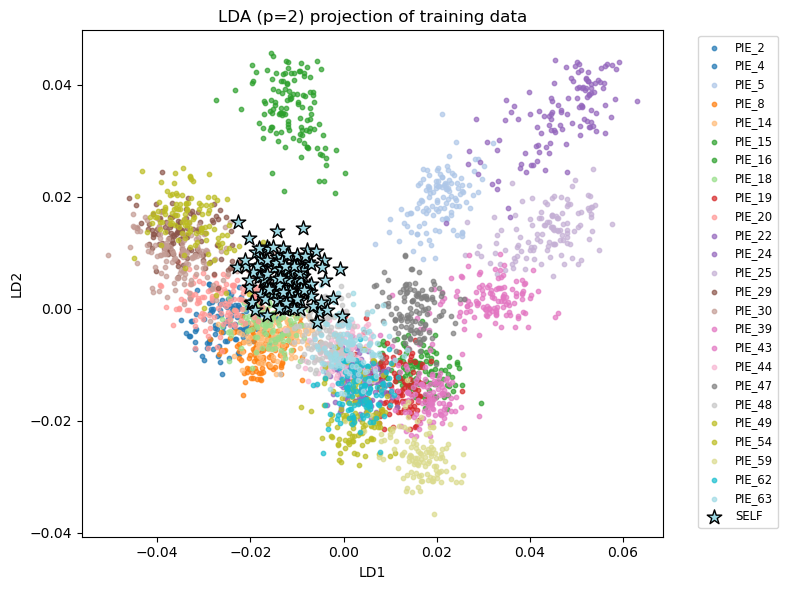

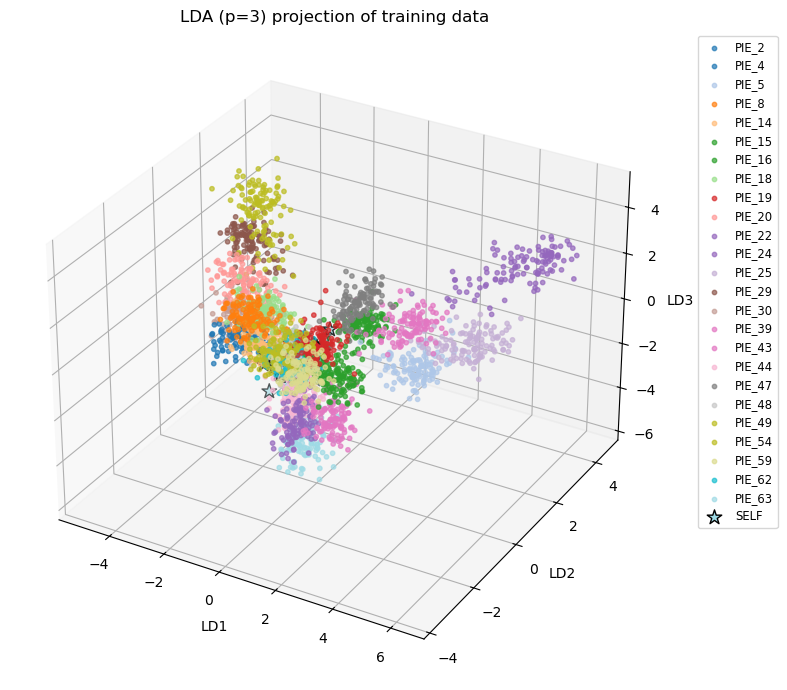

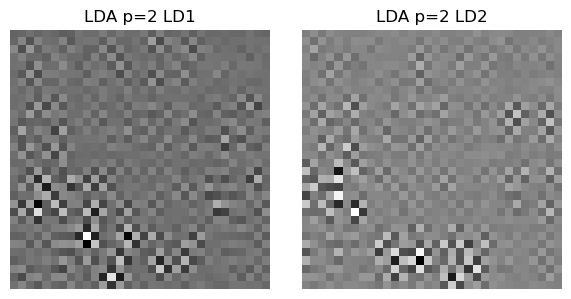

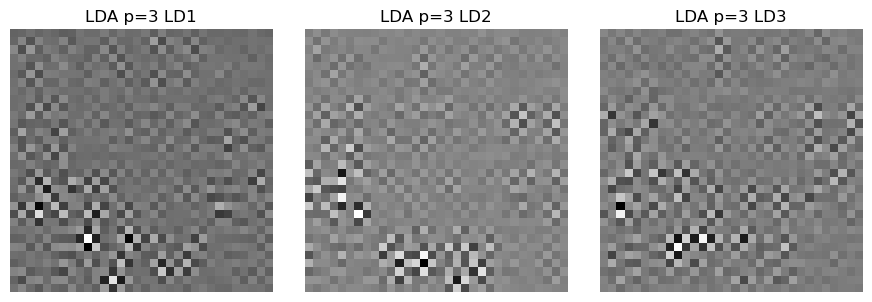

LDA p=10:
  X_train_lda10 shape: (2982, 10)
  X_test_lda10 shape : (1278, 10)
  LDA(10) eigenvalues: [21.46179303 14.8192683  12.2839566  11.23228022 10.5885052   9.68319905
  9.02835323  8.56343651  8.07430042  7.47479707]

LDA p=20:
  X_train_lda20 shape: (2982, 20)
  X_test_lda20 shape : (1278, 20)
  LDA(20) eigenvalues: [21.46179303 14.8192683  12.2839566  11.23228022 10.5885052   9.68319905
  9.02835323  8.56343651  8.07430042  7.47479707  7.10589018  6.80548633
  6.52799054  6.22516318  6.03516932  5.59995806  5.54140954  5.37910387
  4.8644303   4.57397138]


In [3]:
import numpy as np
from typing import Optional


## 1.3 LDA for feature extraction and visualization


# ==========================================================
# LDA
# ==========================================================


class MyLDA:
    """
    Simple LDA implementation:
        - N: number of LDA projection directions to keep
        - fit(X, y):    compute LDA on training data
        - transform(X): project new data onto LDA subspace
        - fit_transform(X, y): convenience method
    """

    def __init__(self, P: int):
        self.P: int = P
        self.mean = None  # Total mean, (D,)
        self.scalings = None  # LDA directions,(p, D)
        self.eigvals = None  # eigenvalues, (p,)
        self.class_means = None  # class-specific means, (C, D)

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Fit LDA on data X with labels y.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data matrix; each row is one flattened image.
        y : ndarray of shape (n_samples,)
            Class labels (0, 1, ..., C-1).
        """
        n_samples, n_features = X.shape
        classes = np.unique(y)  # Extract the class
        n_classes = len(classes)

        if self.P > n_classes - 1:  # Upperbound
            raise ValueError(
                f"LDA can provide at most (n_classes - 1) directions, "
                f"got N={self.P}, n_classes={n_classes}."
            )

        # 1. Compute total mean
        mean_total = np.mean(X, axis=0)  # (1, D)
        self.mean = mean_total

        # 2. Initialize within-class and between-class scatter matrices
        Sw = np.zeros((n_features, n_features), dtype=np.float64)
        Sb = np.zeros((n_features, n_features), dtype=np.float64)

        class_means = []

        # 3. Compute class means and scatter matrices
        for c in classes:
            Xc = X[y == c]  # samples of class c, shape (Nc, D)
            mean_c = np.mean(Xc, axis=0)  # class mean, shape (1, D)
            class_means.append(mean_c)

            # Within-class scatter
            Xc_centered = Xc - mean_c  # (Nc, D)
            Sw += Xc_centered.T @ Xc_centered  # (D, D)

            # Between-class scatter
            mean_diff = (mean_c - mean_total).reshape(-1, 1)  # (D, 1)
            Nc = Xc.shape[0]  # class size
            Sb += Nc * (mean_diff @ mean_diff.T)  # (D, D)

        self.class_means = np.vstack(class_means)  # (C, D)

        # 4. Solve the generalized eigenvalue problem:
        #    (Sw^-1 Sb) w = lambda w
        Sw_inv = np.linalg.pinv(Sw)  # Use pseudo-inverse of Sw in case it's singular.
        M = Sw_inv @ Sb  # (D, D)

        eigvals, eigvecs = np.linalg.eig(M)  # use eig to aviod asysmetric M
        eigvals = eigvals.real  # Keep real parts
        eigvecs = eigvecs.real

        # 5. Sort eigenvalues and eigenvectors in descending order
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        # 6. Keep the first N directions
        p = self.P
        self.scalings = eigvecs[:, :p].T  # (p, D), each row is one LDA direction
        self.eigvals = eigvals[:p]  # (p,)

        return self

    def transform(self, X: np.ndarray):
        """
        Project data X onto the LDA subspace.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)

        Returns
        -------
        Z : ndarray of shape (n_samples, N)
            Low-dimensional representation of X in the LDA space.
        """
        if self.mean is None or self.scalings is None:
            raise RuntimeError("MyLDA is not fitted yet. Call fit(X, y) first.")

        # Center input using overall mean used in training (optional but consistent)
        X_centered = X - self.mean  # (N, D)

        # Project data onto LDA directions
        Z = X_centered @ self.scalings.T  # (N, p)
        return Z

    def fit_transform(self, X: np.ndarray, y: np.ndarray):
        """
        Qucik fit and transform
        """
        self.fit(X, y)
        return self.transform(X)


# ==========================================================
# Apply LDA with number of PCs to be 2 and 3
# ==========================================================

lda2 = MyLDA(P=2)
Z_train_lda2 = lda2.fit_transform(X_train, y_train)  # shape: (n_train, 2)

print("LDA p=2:")
print("  Z_train_lda2 shape:", Z_train_lda2.shape)
print("  LDA(2) scalings_ shape:", lda2.scalings.shape)  # (2, 1024)
print("  LDA(2) eigenvalues:", lda2.eigvals)


lda3 = MyLDA(P=3)
Z_train_lda3 = lda3.fit_transform(X_train, y_train)  # shape: (n_train, 3)

print("\nLDA p=3:")
print("  Z_train_lda3 shape:", Z_train_lda3.shape)
print("  LDA(3) scalings_ shape:", lda3.scalings.shape)  # (3, 1024)
print("  LDA(3) eigenvalues:", lda3.eigvals)


# ==========================================================
# Visualization
# ==========================================================

# Call the function for p = 2
plot_2d(
    Z_train_lda2,
    y_train,
    class_names,
    self_class_idx,
    xlabel="LD1",
    ylabel="LD2",
    title="LDA (p=2) projection of training data",
)


# Call the function for p = 3
plot_3d(
    Z_train_lda3 * 100,
    y_train,
    class_names,
    self_class_idx,
    xlabel="LD1",
    ylabel="LD2",
    zlabel="LD3",
    title="LDA (p=3) projection of training data",
)


# ==========================================================
# Fisherface
# ==========================================================


def show_fisherfaces(
    directions: np.ndarray, img_shape=(32, 32), num_faces=None, title_prefix=""
):
    """
    Visualize by reshaping LDA directions as 2D images.

    Parameters
    ----------
    directions : ndarray of shape (p, D)
        Each row is one LDA direction vector.
    img_shape : tuple
        Shape of the original image (height, width).
    num_faces : int or None
        Number of fisherfaces to show. If None, use all directions.
    title_prefix : str
        Text prefix for subplot titles.
    """
    if directions is None:
        raise ValueError("directions is None. Make sure LDA has been fitted.")

    if num_faces is None:
        num_faces = directions.shape[0]

    plt.figure(figsize=(3 * num_faces, 3))

    for i in range(num_faces):
        vec = directions[i]  # shape: (D,)
        fisherface = vec.reshape(img_shape)

        # Normalize to [0,1] for better visualization
        f_min, f_max = fisherface.min(), fisherface.max()
        if f_max > f_min:
            fisherface_norm = (fisherface - f_min) / (f_max - f_min)
        else:
            fisherface_norm = np.zeros_like(fisherface)

        plt.subplot(1, num_faces, i + 1)
        plt.imshow(fisherface_norm, cmap="gray")
        plt.title(f"{title_prefix} LD{i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Fisherfaces for LDA with p = 2
show_fisherfaces(
    directions=lda2.scalings, img_shape=(32, 32), num_faces=2, title_prefix="LDA p=2"
)

# Fisherfaces for LDA with p = 3
show_fisherfaces(
    directions=lda3.scalings, img_shape=(32, 32), num_faces=3, title_prefix="LDA p=3"
)


# ================================================
# LDA with p = 10 & 20
# ================================================

# Create an LDA model that keeps 10 projection directions
lda10 = MyLDA(P=10)

# Fit LDA on the TRAINING data only and obtain 10-D LDA features
X_train_lda10 = lda10.fit_transform(X_train, y_train)  # shape: (n_train, 10)

# Use the same LDA model to transform TEST data
X_test_lda10 = lda10.transform(X_test)  # shape: (n_test, 10)

print("LDA p=10:")
print("  X_train_lda10 shape:", X_train_lda10.shape)
print("  X_test_lda10 shape :", X_test_lda10.shape)
print("  LDA(10) eigenvalues:", lda10.eigvals)



# Create another LDA model that keeps 20 projection directions
lda20 = MyLDA(P=20)

# Fit LDA on the same TRAINING data and obtain 20-D LDA features
X_train_lda20 = lda20.fit_transform(X_train, y_train)  # shape: (n_train, 20)

# Transform TEST data with the LDA(20) model
X_test_lda20 = lda20.transform(X_test)  # shape: (n_test, 20)

print("\nLDA p=20:")
print("  X_train_lda20 shape:", X_train_lda20.shape)
print("  X_test_lda20 shape :", X_test_lda20.shape)
print("  LDA(20) eigenvalues:", lda20.eigvals)

In [4]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# 2. Part2 Pattern Recognition


## 2.1 KNN for classification

# ==========================================================
# KNN & Accuracy Calculation
# ==========================================================


def knn_eval(
    name: str,
    X_train_feat,
    X_test_feat,
    y_train,
    y_test,
    self_class_idx,
    k=1,
    metric="euclidean",
):
    """
    Train a KNN(k) on given features and output test accuracy

    Parameters
    ----------
    name : str
        Name of the feature space.
    X_train_feat : ndarray of shape (n_train, d)
        Training features.
    X_test_feat : ndarray of shape (n_test, d)
        Test features.
    y_train, y_test : ndarray
        Labels.
    self_class_idx : int
        Integer label id of SELF class
    k : int
        Number of neighbors in KNN.
    """
    # 1) Train KNN
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
    knn.fit(X_train_feat, y_train)

    # 2) Predict the Class label
    y_pred = knn.predict(X_test_feat)

    # 3) Calculate the accuracy for different set of samples
    acc_all = knn.score(X_test_feat, y_test)
    mask_pie = y_test != self_class_idx
    mask_self = ~mask_pie
    acc_pie = accuracy_score(y_test[mask_pie], y_pred[mask_pie])
    acc_self = accuracy_score(y_test[mask_self], y_pred[mask_self])

    # 4) Output the result
    print(f"\n=== KNN (k={k}) — {name} ===")
    print(f"Overall test accuracy : {acc_all:.4f}")
    print(f"CMU PIE accuracy      : {acc_pie:.4f}")
    print(f"SELF accuracy         : {acc_self:.4f}")


# ================================================
# Run for differenr feature sets
# ================================================

self_class_idx = class_names.index("SELF")
print("SELF class index:", self_class_idx)

feature_sets = [
    ("PCA-100 features (p=100)", "X_train_pca100", "X_test_pca100"),
    ("PCA-300 features (p=300)", "X_train_pca300", "X_test_pca300"),
    ("LDA-10 features (p=10)", "X_train_lda10", "X_test_lda10"),
    ("LDA-20 features (p=20)", "X_train_lda20", "X_test_lda20"),
]

Metric = "euclidean"

for name, tr_key, te_key in feature_sets:
    if tr_key in globals() and te_key in globals():
        res = knn_eval(
            name=name,
            X_train_feat=globals()[tr_key],
            X_test_feat=globals()[te_key],
            y_train=y_train,
            y_test=y_test,
            self_class_idx=self_class_idx,
            metric=Metric,
        )

SELF class index: 25

=== KNN (k=1) — PCA-100 features (p=100) ===
Overall test accuracy : 0.9491
CMU PIE accuracy      : 0.9469
SELF accuracy         : 1.0000

=== KNN (k=1) — PCA-300 features (p=300) ===
Overall test accuracy : 0.9531
CMU PIE accuracy      : 0.9510
SELF accuracy         : 1.0000

=== KNN (k=1) — LDA-10 features (p=10) ===
Overall test accuracy : 0.9437
CMU PIE accuracy      : 0.9453
SELF accuracy         : 0.9074

=== KNN (k=1) — LDA-20 features (p=20) ===
Overall test accuracy : 0.9577
CMU PIE accuracy      : 0.9592
SELF accuracy         : 0.9259


SELF class index: 25
[Raw 1024 features] Cluster label counts: [401 493 384]


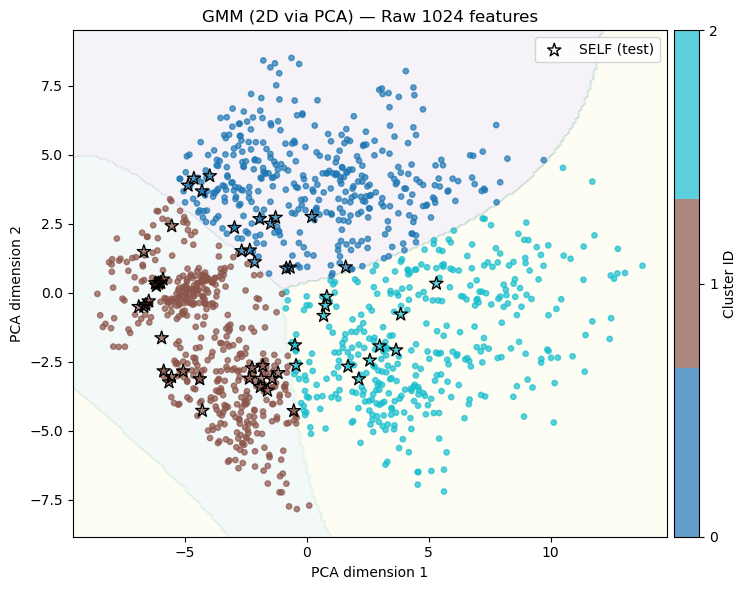

[PCA-100 features] Cluster label counts: [401 493 384]


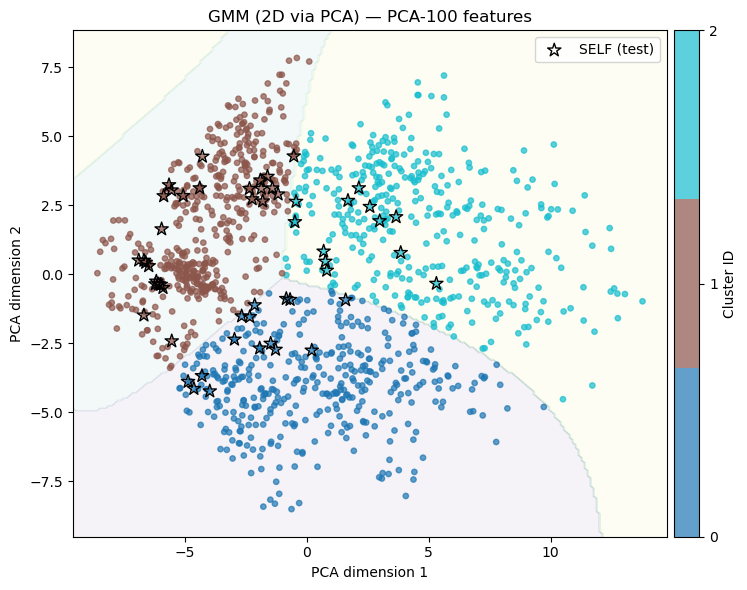

[PCA-300 features] Cluster label counts: [401 493 384]


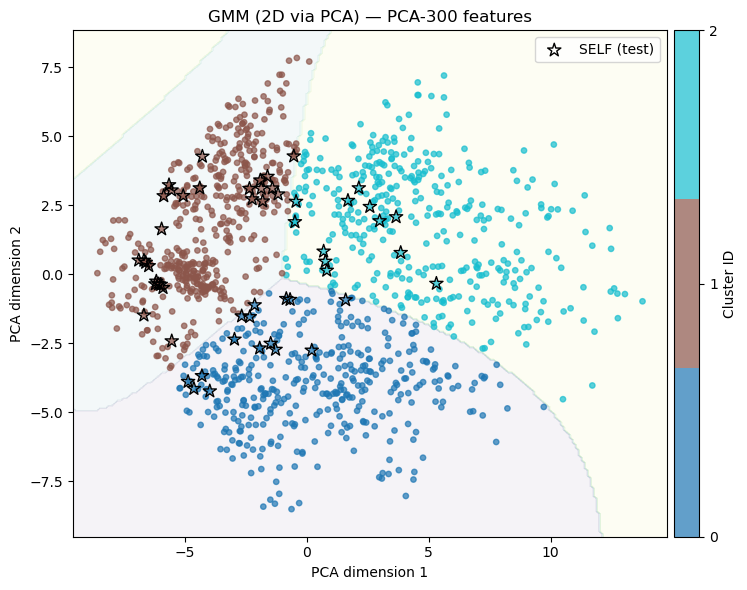

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.inspection import DecisionBoundaryDisplay


## 2.2 GMM for clustering


# ================================================
# PCA, GMM & 2D visualization
# ================================================


def gmm_vis2d(
    name,
    X_train_feat,
    X_test_feat,
    y_test,
    self_class_idx,
    n_components=3,
    random_state=SEED,
    grid_resolution=200,
):
    """
    Perform PCA for 2D visualization, train a GMM, plot decision regions,
    scatter test samples, and highlight SELF samples.

    Parameters
    ----------
    name : str
        Name of the feature space.
    X_train_feat : ndarray of shape (n_train, d)
        Training features.
    X_test_feat : ndarray of shape (n_test, d)
        Test features.
    y_train, y_test : ndarray
        Labels.
    self_class_idx : int
        Integer label id of SELF class
    n_components : int
        Number of Gaussian components (clusters) for the GMM.
    """
    # 1) Reduce dimension to 2D (fit on training data, transform both)
    pca2 = PCA(n_components=2, random_state=random_state)
    X_train_2d = pca2.fit_transform(X_train_feat)
    X_test_2d = pca2.transform(X_test_feat)

    # 2) Train GMM on the 2D training projection
    gmm2d = GaussianMixture(
        n_components=n_components, covariance_type="full", random_state=random_state
    )
    gmm2d.fit(X_train_2d)

    # 3) Predict cluster labels for the 2D test projection
    y_cluster = gmm2d.predict(X_test_2d)
    print(
        f"[{name}] Cluster label counts:",
        np.bincount(y_cluster, minlength=n_components),
    )

    # 4) Plot decision regions
    fig, ax = plt.subplots(figsize=(8, 6))
    DecisionBoundaryDisplay.from_estimator(
        gmm2d,
        X_test_2d,
        response_method="predict",
        ax=ax,
        alpha=0.05,
        grid_resolution=grid_resolution,
    )

    # 5) Plot test samples, colored by cluster
    sc = ax.scatter(
        X_test_2d[:, 0],
        X_test_2d[:, 1],
        c=y_cluster,
        s=15,
        alpha=0.7,
        cmap=plt.get_cmap("tab10", n_components),
        # edgecolors="black"
    )

    # 6) Highlight SELF test samples
    mask_self = y_test == self_class_idx
    ax.scatter(
        X_test_2d[mask_self, 0],
        X_test_2d[mask_self, 1],
        s=100,
        marker="*",
        facecolors="none",
        edgecolors="black",
        linewidths=1,
        label="SELF (test)",
    )

    # 7) Add labels, title, legend, and colorbar
    ax.set_xlabel("PCA dimension 1")
    ax.set_ylabel("PCA dimension 2")
    ax.set_title(f"GMM (2D via PCA) — {name}")
    ax.legend(loc="upper right")
    cbar = plt.colorbar(sc, ax=ax, ticks=range(n_components), pad=0.01)
    cbar.set_label("Cluster ID")
    plt.tight_layout()
    plt.show()



# ================================================
# Run for different feature sets
# ================================================

self_class_idx = class_names.index("SELF")
print("SELF class index:", self_class_idx)

feature_sets = [
    ("Raw 1024 features", "X_train", "X_test"),
    ("PCA-100 features", "X_train_pca100", "X_test_pca100"),
    ("PCA-300 features", "X_train_pca300", "X_test_pca300"),
]

# Automatically run for all existing feature sets
for name, tr_key, te_key in feature_sets:
    if tr_key in globals() and te_key in globals():
        gmm_vis2d(
            name,
            globals()[tr_key],
            globals()[te_key],
            y_test,
            self_class_idx,
        )

In [6]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


## 2.3 SVM for classification


# ================================================
# Linear SVM & Accuracy Calculation
# ================================================


def linear_svm_eval(
    name: str,
    X_train_feat,
    X_test_feat,
    y_train,
    y_test,
    Cs = [0.01, 1, 100],
    random_state = SEED,
):
    """
    Run Linear SVM with different C values on given feature representations.

    Parameters
    ----------
    name : str
        Name of the feature space.
    X_train_feat : ndarray of shape (n_train, d)
        Training features.
    X_test_feat : ndarray of shape (n_test, d)
        Test features.
    y_train, y_test : ndarray
        Labels.
    Cs : iterable
        List of C values to try.
    """
    print(f"\n=== Linear SVM on {name} ===")
    
    # Iterate over all Cs
    for C in Cs:
        # 1) Train Linear SVM
        svm = LinearSVC(C=C, multi_class="ovr", random_state=random_state, max_iter=10000)
        svm.fit(X_train_feat, y_train)

        # 2) Predict the label for both testing and trainng data
        y_train_pred = svm.predict(X_train_feat)
        y_test_pred = svm.predict(X_test_feat)

        # 3) Calculate the accuracy
        acc_train = accuracy_score(y_train, y_train_pred)
        acc_test = accuracy_score(y_test, y_test_pred)

        print(
            f"C = {C:6.2f}  |  Train acc: {acc_train:.4f}  |  Test acc: {acc_test:.4f}"
        )


# ================================================
# Run for all existing feature sets
# ================================================

feature_sets = [
    ("Raw 1024 features", "X_train", "X_test"),
    ("PCA-100 features", "X_train_pca100", "X_test_pca100"),
    ("PCA-300 features", "X_train_pca300", "X_test_pca300"),
    ("LDA-10 features", "X_train_lda10", "X_test_lda10"),
    ("LDA-20 features", "X_train_lda20", "X_test_lda20"),
]

for name, tr_key, te_key in feature_sets:
    if tr_key in globals() and te_key in globals():
        linear_svm_eval(
            name,
            globals()[tr_key],
            globals()[te_key],
            y_train,
            y_test
        )


=== Linear SVM on Raw 1024 features ===
C =   0.01  |  Train acc: 0.9826  |  Test acc: 0.9656
C =   1.00  |  Train acc: 1.0000  |  Test acc: 0.9828
C = 100.00  |  Train acc: 1.0000  |  Test acc: 0.9836

=== Linear SVM on PCA-100 features ===
C =   0.01  |  Train acc: 0.9705  |  Test acc: 0.9546
C =   1.00  |  Train acc: 0.9990  |  Test acc: 0.9797
C = 100.00  |  Train acc: 1.0000  |  Test acc: 0.9797

=== Linear SVM on PCA-300 features ===
C =   0.01  |  Train acc: 0.9795  |  Test acc: 0.9671
C =   1.00  |  Train acc: 1.0000  |  Test acc: 0.9859
C = 100.00  |  Train acc: 1.0000  |  Test acc: 0.9828

=== Linear SVM on LDA-10 features ===
C =   0.01  |  Train acc: 0.7284  |  Test acc: 0.6721
C =   1.00  |  Train acc: 0.9514  |  Test acc: 0.8584
C = 100.00  |  Train acc: 0.9913  |  Test acc: 0.9163

=== Linear SVM on LDA-20 features ===
C =   0.01  |  Train acc: 0.9349  |  Test acc: 0.8991
C =   1.00  |  Train acc: 0.9990  |  Test acc: 0.9546
C = 100.00  |  Train acc: 0.9990  |  Test acc

In [7]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import random


# ================================================
# Random Seed configuration
# ================================================

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ================================================
# Custom dataset
# ================================================


class Flat1024Faces(Dataset):
    """
    Create a simple custom dataset for 32x32 grayscale faces.

    Parameters
    ----------
    X_flat : ndarray of shape (N, 1024)
        Flattened images (each row is a 32x32 face).
    y : ndarray of shape (N,)
        Integer class labels.
    """

    def __init__(self, X_flat: np.ndarray, y: np.ndarray):
        # guarantee the sahpe (N,1024)
        N, D = X_flat.shape
        if D != 1024:
            raise ValueError(f"Expected feature dim = 1024, got {D}")

        # Reshape to (N, 1, 32, 32)
        X = X_flat.reshape(N, 1, 32, 32).astype(np.float32)

        # Normalize to [0, 1] if needed
        if X.max() > 1:
            X = X / 255.0

        self.X = X
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])  # (1,32,32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


# ================================================
# CNN model
# ================================================


class FaceCNN(nn.Module):
    """ """

    def __init__(self, num_classes=len(class_names)):  # grayscale, 26 classes
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1, out_channels=20, kernel_size=5, stride=1, padding=0
            ),  # 32->28
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28->14
            nn.Conv2d(
                in_channels=20, out_channels=50, kernel_size=5, stride=1, padding=0
            ),  # 14->10
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 10->5
        )
        self.classifier = nn.Sequential(
            nn.Linear(50 * 5 * 5, 500),
            nn.ReLU(inplace=True),
            nn.Linear(500, out_features=num_classes),  # CrossEntropyLoss include softmax
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # (N, 1250)
        return self.classifier(x)


# ================================================
# Model training and predicting
# ================================================


def _run_epoch(model, loader, optimizer, criterion, train: bool):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, ys, ps = 0.0, [], []
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            ys.append(yb.detach().cpu().numpy())
            ps.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
    ys = np.concatenate(ys)
    ps = np.concatenate(ps)
    return total_loss / len(loader.dataset), accuracy_score(ys, ps)


# ================================================
# Main
# ================================================


def cnn_eval(
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=128,
    epochs=30,
    lr=1e-3,
    weight_decay=0.0,
):
    """
    Run CNN on given datasets and report performance.

    Parameters
    ----------
    name : str
        Name of the feature space.
    X_train : ndarray of shape (n_train, d)
        Training dataset (Flattened images).
    X_test : ndarray of shape (n_test, d)
        Test dataset.
    y_train, y_test : ndarray
        Labels.
    batch_size : int, here default=128
        Number of samples per batch during training and evaluation.
    epochs : int, default=30
        Number of full passes over the training set.
    lr : float, default=1e-3
        Learning rate for the optimizer.
    """
    # 封装数据
    ds_tr = Flat1024Faces(X_train, y_train)
    ds_te = Flat1024Faces(X_test, y_test)

    tr_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0)
    te_loader = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0)

    # 构建模型（灰度 -> in_channels=1）
    model = FaceCNN(num_classes=26).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=lr, weight_decay=weight_decay)

    best_te = 0.0
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = _run_epoch(model, tr_loader, optimizer, criterion, train=True)
        te_loss, te_acc = _run_epoch(
            model, te_loader, optimizer, criterion, train=False
        )
        best_te = max(best_te, te_acc)
        print(
            f"Epoch {ep:02d}/{epochs} | "
            f"Train {tr_loss:.4f}/{tr_acc*100:.2f}% | "
            f"Test {te_loss:.4f}/{te_acc*100:.2f}% | "
            f"Best {best_te*100:.2f}%"
        )

    # 最终报告
    tr_loss, tr_acc = _run_epoch(model, tr_loader, optimizer, criterion, train=False)
    te_loss, te_acc = _run_epoch(model, te_loader, optimizer, criterion, train=False)
    print("\n=== Final Report ===")
    print(f"Training Accuracy: {tr_acc*100:.2f}%")
    print(f"Testing  Accuracy: {te_acc*100:.2f}%")


# -----------------------
# 用法示例（取消注释即可运行）
# -----------------------
cnn_eval(X_train, y_train, X_test, y_test, batch_size=128, epochs=30, lr=1e-1)

Epoch 01/30 | Train 3.2277/4.63% | Test 3.1866/8.06% | Best 8.06%
Epoch 02/30 | Train 3.1221/8.32% | Test 3.0185/10.17% | Best 10.17%
Epoch 03/30 | Train 2.8240/17.54% | Test 3.1685/17.14% | Best 17.14%
Epoch 04/30 | Train 2.5856/26.02% | Test 2.7742/16.43% | Best 17.14%
Epoch 05/30 | Train 2.9375/19.89% | Test 2.2291/39.59% | Best 39.59%
Epoch 06/30 | Train 1.7975/46.41% | Test 1.3515/58.37% | Best 58.37%
Epoch 07/30 | Train 0.9239/72.07% | Test 0.7739/77.46% | Best 77.46%
Epoch 08/30 | Train 0.7085/77.63% | Test 0.4624/86.93% | Best 86.93%
Epoch 09/30 | Train 0.3555/88.77% | Test 0.6137/82.55% | Best 86.93%
Epoch 10/30 | Train 0.3508/88.87% | Test 0.3840/89.20% | Best 89.20%
Epoch 11/30 | Train 0.1828/94.33% | Test 0.3868/88.97% | Best 89.20%
Epoch 12/30 | Train 0.2424/92.45% | Test 0.4202/88.18% | Best 89.20%
Epoch 13/30 | Train 0.1479/95.17% | Test 0.2710/92.72% | Best 92.72%
Epoch 14/30 | Train 0.1469/95.31% | Test 0.4404/89.91% | Best 92.72%
Epoch 15/30 | Train 0.1665/95.14% | Te